## Интеллектуальный анализ данных – весна 2025
## Домашнее задание 4: kNN. Линейные модели. Работа с признаками

Правила:

* Домашнее задание оценивается в 10 баллов.

* Можно использовать без доказательства любые результаты, встречавшиеся на лекциях или семинарах по курсу, если получение этих результатов не является вопросом задания.

* Можно использовать любые свободные источники с *обязательным* указанием ссылки на них.

* Плагиат не допускается. При обнаружении случаев списывания, 0 за работу выставляется всем участникам нарушения, даже если можно установить, кто у кого списал.

* Старайтесь сделать код как можно более оптимальным. В частности, будет штрафоваться использование циклов в тех случаях, когда операцию можно совершить при помощи инструментов библиотек, о которых рассказывалось в курсе.  

* Если в задании есть вопрос на рассуждение, то за отсутствие ответа на него балл за задание будет снижен вполовину.

### Задание 1:  Визуализация решающих поверхностей в kNN.

В этом задании мы изобразим решающую поверхность для классификатора kNN, чтобы наглядно увидеть, как классификатор принимает решения для новых объектов. Для простоты будем работать с усеченным датасетом `Palmer Penguins`, содержащим информацию о характеристиках трех видов пингвинов: `Adelie`, `Chinstrap` и `Gentoo`:



*   Species — вид пингвина (целевая переменная).
*   Island — остров, на котором была сделана запись.
*   Clutch Completion — завершенность кладки яиц.
*   Date Egg — закодированная дата откладки яиц (число дней от самой ранней даты в данных).
*   Culmen Length (mm) — длина клюва.
*   Culmen Depth (mm) — глубина клюва.
*   Flipper Length (mm) — длина ласт.
*   Body Mass (g) — масса тела в граммах.
*   Sex — пол особи.
*   Delta 15 N (o/oo) и Delta 13 C (o/oo) — изотопные значения, характеризующие пищевые предпочтения.

Описание полного набора данных и дополнительную информацию о проекте можно найти [здесь](https://allisonhorst.github.io/palmerpenguins/index.html) и [здесь](https://www.kaggle.com/datasets/parulpandey/palmer-archipelago-antarctica-penguin-data?resource=download).

![Palmer Penguins](https://allisonhorst.github.io/palmerpenguins/reference/figures/lter_penguins.png)



In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
data = pd.read_csv('penguins_data.csv')
data.head(10)

,Species,Island,Clutch Completion,Date Egg,Culmen Length (mm),Culmen Depth (mm),Flipper Length (mm),Body Mass (g),Sex,Delta 15 N (o/oo),Delta 13 C (o/oo)
0,Chinstrap,Dream,Yes,382,50.9,19.1,196.0,3550.0,MALE,10.02372,-24.86594
1,Chinstrap,Dream,Yes,741,45.2,17.8,198.0,3950.0,FEMALE,8.88942,-24.49433
2,Gentoo,Biscoe,Yes,744,46.5,13.5,210.0,4550.0,FEMALE,7.99530,-25.32829
3,Chinstrap,Dream,Yes,10,45.2,16.6,191.0,3250.0,FEMALE,9.62357,-24.78984
4,Gentoo,Biscoe,Yes,13,48.4,14.4,203.0,4625.0,FEMALE,8.16582,-26.13971
5,Gentoo,Biscoe,Yes,22,48.1,15.1,209.0,5500.0,MALE,8.45738,-26.22664
6,Gentoo,Biscoe,Yes,13,51.1,16.5,225.0,5250.0,MALE,8.20660,-26.36863
7,Gentoo,Biscoe,No,392,42.7,13.7,208.0,3950.0,FEMALE,8.14567,-26.59467
8,Adelie,Biscoe,Yes,14,39.6,20.7,191.0,3900.0,FEMALE,8.80967,-26.78958
9,Gentoo,Biscoe,Yes,735,46.1,13.2,211.0,4500.0,FEMALE,7.99300,-25.51390


**Задача 1.1 (0.5 балла)** Есть ли в наборе данных пропущенные значения? Если да, то удалите их. Есть ли в наборе данных категориальные признаки? Если да, то закодируйте их самым оптимальным способом. Аргументируйте свой выбор.

In [3]:
data.isna().sum()

Species                 0
Island                  0
Clutch Completion       0
Date Egg                0
Culmen Length (mm)      2
Culmen Depth (mm)       2
Flipper Length (mm)     2
Body Mass (g)           2
Sex                    10
Delta 15 N (o/oo)      14
Delta 13 C (o/oo)      13
dtype: int64

В наборе данных есть пропуски, поэтому удалим их:

In [4]:
data = data.dropna()

Выведем все значения которые принимают категориальные признаки:

In [5]:
data.info()

<class 'pandas.DataFrame'>
Index: 325 entries, 0 to 343
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Species              325 non-null    str    
 1   Island               325 non-null    str    
 2   Clutch Completion    325 non-null    str    
 3   Date Egg             325 non-null    int64  
 4   Culmen Length (mm)   325 non-null    float64
 5   Culmen Depth (mm)    325 non-null    float64
 6   Flipper Length (mm)  325 non-null    float64
 7   Body Mass (g)        325 non-null    float64
 8   Sex                  325 non-null    str    
 9   Delta 15 N (o/oo)    325 non-null    float64
 10  Delta 13 C (o/oo)    325 non-null    float64
dtypes: float64(6), int64(1), str(4)
memory usage: 30.5 KB


In [6]:
data["Species"].value_counts()

Species
Adelie       139
Gentoo       119
Chinstrap     67
Name: count, dtype: int64

In [7]:
data["Island"].value_counts()

Island
Biscoe       163
Dream        119
Torgersen     43
Name: count, dtype: int64

In [8]:
data["Clutch Completion"].value_counts()

Clutch Completion
Yes    291
No      34
Name: count, dtype: int64

In [9]:
data["Sex"].value_counts()

Sex
FEMALE    163
MALE      161
.           1
Name: count, dtype: int64

Удалим строку в которой Sex = '.'

In [10]:
data = data[data["Sex"] != "."]

Закодируем `Clutch Completion` и `Sex` как бинарные признаки, т.к. они принимают только 2 уникальных значения 

In [11]:
data["Clutch Completion"] = data["Clutch Completion"].map({
    "Yes": 1,
    "No": 0
})

In [12]:
data["Sex"] = data["Sex"].map({
    "MALE": 1,
    "FEMALE": 0
})

> в целом One-Hot с drop_first дал бы тот же результат, но ладно

Закодируем `Island` с помощью OneHotEncoding, т.к. больше 2 уникальных значений (первый столбец дропаем, т.к. если все остальные False, то значение и так понятно)

In [13]:
data = pd.get_dummies(data, columns=["Island"], drop_first=True)

In [14]:
data["Species"] = data["Species"].map({
    "Chinstrap": 0,
    "Gentoo": 1,
    "Adelie": 2
})

In [15]:
data.sample()

,Species,Clutch Completion,Date Egg,Culmen Length (mm),Culmen Depth (mm),Flipper Length (mm),Body Mass (g),Sex,Delta 15 N (o/oo),Delta 13 C (o/oo),Island_Dream,Island_Torgersen
171,2,1,13,37.3,20.5,199.0,3775.0,1,9.49645,-26.36678,False,True


Целевую категориальную переменную закодируйте в ординальном порядке: Chinstrap = 0, Gentoo = 1, Adelie = 2. Можно воспользоваться [OrdinalEncoder](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.OrdinalEncoder.html).

Теперь сохраним информацию о признаках в переменную
`X`, а о целевой переменной – в переменную `y`.

In [16]:
X, y = data.drop(columns=["Species"]), data["Species"]

**Задача 1.2 (0.5 балла)** Используя функцию `train_test_split()`, разделите выборку на тренировочную и тестовую, и долю тестовой выборки задайте равной 0.3. Так как разбиение осуществляется случайным образом, не забудьте зафиксировать `np.random.seed()` для воспроизводимости результатов.

Используйте аргумент `stratify` при разбиении. Почему это важно?

In [17]:
from sklearn.model_selection import train_test_split

np.random.seed(67)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y)

`stratify` важно использовать, т.к. без него, при случайном разбиении, в какую-то из выборок может попасть недостаточно значений какого-либо класса.   

**Задача 1.3 (1 балл)** На тренировочной выборке обучите шесть классификаторов kNN, отличающихся только числом соседей. Для первого классификатора число соседей поставьте равным 1, для второго - 3, для третьего – 5, для четвертого – 10, для пятого – 15 и для шестого – 25 (обратите внимание на параметр `n_neighbours` класса `KNeighborsClassifier`). Для обучения используйте только два признака:  `Flipper Length (mm)` и `Body Mass (g)`  – и евклидово расстояние. Не забудьте масштабировать признаки, например, при помощи модуля `StandardScaler`.

Выведите долю правильных ответов на тренировочной и тестовой выборках для каждого классификатора.

In [18]:
X_train_knn = X_train[["Flipper Length (mm)", "Body Mass (g)"]]
X_test_knn = X_test[["Flipper Length (mm)", "Body Mass (g)"]]

In [19]:
from sklearn.preprocessing import StandardScaler


standard_scaler = StandardScaler()
X_train_knn = standard_scaler.fit_transform(X_train_knn)
X_test_knn = standard_scaler.transform(X_test_knn)

In [20]:
from sklearn.neighbors import KNeighborsClassifier


k_values = [1, 3, 5, 10, 15, 25]
knns = dict()

print("NN \t Train \t Test")
for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k, metric="euclidean")
    model.fit(X_train_knn, y_train)
    knns[k] = model
    
    train_score = model.score(X_train_knn, y_train)
    test_score = model.score(X_test_knn, y_test)
    
    print(f"{k} \t {train_score:.2f} \t {test_score:.2f}")

NN 	 Train 	 Test
1 	 0.97 	 0.74
3 	 0.91 	 0.71
5 	 0.88 	 0.73
10 	 0.85 	 0.74
15 	 0.85 	 0.76
25 	 0.86 	 0.74


**Задача 1.4 (0 баллов)** Установите библиотеку `mlxtend` командой ниже. Библиотеку также можно установить из терминала при помощи `pip` или `conda`, как указано [здесь](http://rasbt.github.io/mlxtend/installation/).

In [21]:
!pip install mlxtend

Если всё прошло успешно, то в выводе команды выше вы увидите сообщение вроде "successfully installed", а следующая ячейка выполнится без ошибок.

In [22]:
import mlxtend

**Задача 1.5 (1 балл)** Библиотека `mlxtend` позволяет достаточно просто визуализировать решающие поверхности обученных классификаторов. Изучите [документацию](http://rasbt.github.io/mlxtend/user_guide/plotting/plot_decision_regions/) библиотеки и найдите, как можно построить несколько графиков решающих поверхностей на сетке (decision regions grid). Постройте такую сетку графиков для обученных выше классификаторов.

**Подсказки:**
1. Вы можете использовать готовый код, приведённый в документации, и адаптировать его для нашего случая.
2. Вам могут понадобиться дополнительные библиотеки, которые используются в примере из документации.
3. Обратите внимание на то, как нужно изменить параметры `gridspec.GridSpec()` и `itertools.product()` для нашего числа классификаторов.
4. В функции `plot_decision_region()` используйте `y_train` и нужные столбцы из `X_train`. Возможно, их придётся перевести в формат массива `numpy`.
5. Если в задаче 1.3 вы сохраните обученные классификаторы в список, то не будет необходимости обучать их заново.
6. Построение графика может занять некоторое время – придётся немного подождать!

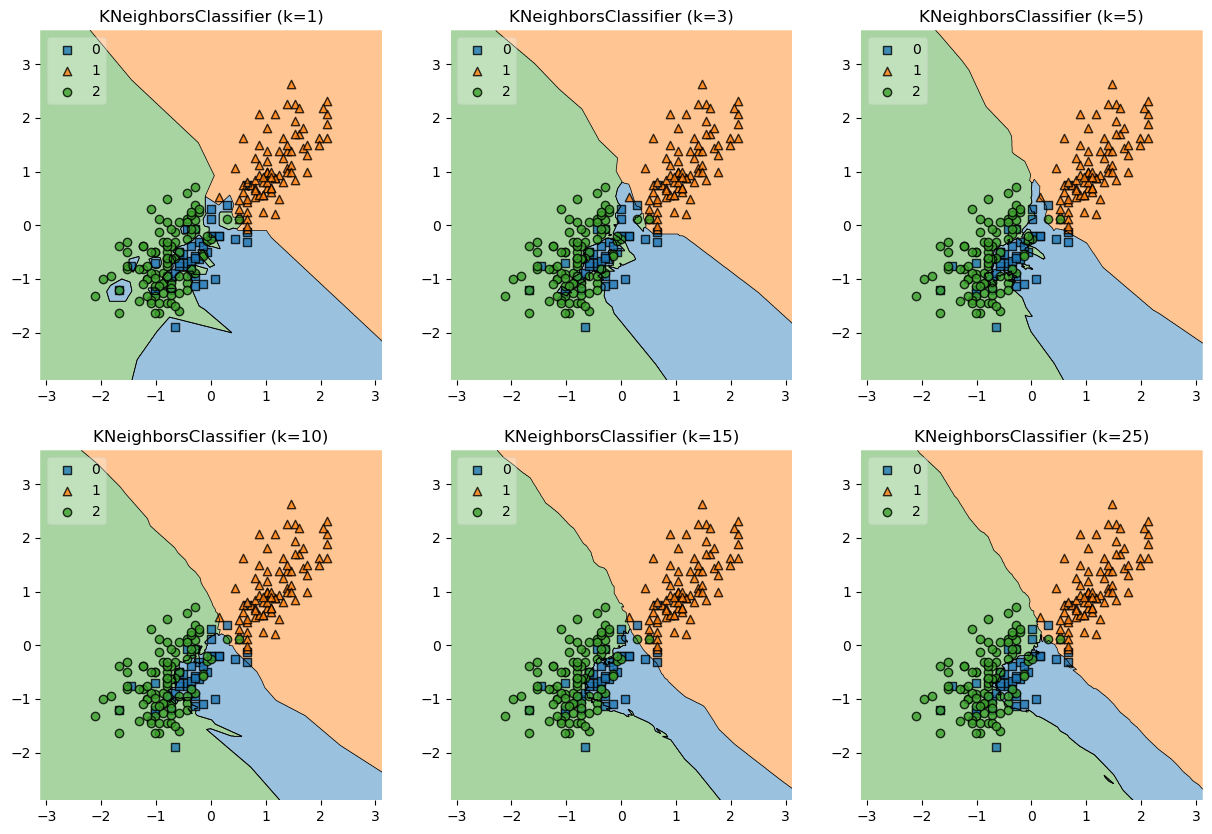

In [23]:
import matplotlib.pyplot as plt
from mlxtend.plotting import plot_decision_regions
import matplotlib.gridspec as gridspec
import itertools
gs = gridspec.GridSpec(2, 3)

fig = plt.figure(figsize=(15,10))

labels = [f"KNeighborsClassifier (k={k})" for k in k_values]
for clf, lab, grd in zip(
    knns.values(),
    labels,
    itertools.product(range(2), range(3))
):
    ax = plt.subplot(gs[grd[0], grd[1]])
    fig = plot_decision_regions(X=X_train_knn, y=np.asarray(y_train), clf=clf, legend=2)
    plt.title(lab)

plt.show()

**Задача 1.6 (0.5 балла)** Прокомментируйте результаты, полученные в задачах 1.3 и 1.5. Какое число соседей оптимально использовать для обучения классификатора? Поясните ваш выбор при помощи описания геометрии данных и получаемой решающей поверхности. Какие из результатов явно говорят о переобучении модели? Почему?

По графикам и скорам видно, что переобучение при k = 1, 3. Модель подстраивается под обучающую выборку, поэтому на решающей поверхности есть маленькие островки.

Я бы сказал, что оптимально брать k = 10 или 15, тк границы становятся более гладкими и хорошо разделяют классы (а еще скор на тесте лучший).

### Задание 2. KNN своими руками. 2,5 балла

**Задача 2.1 (2 балла)** В данном задании мы попробуем реализовать алгоритм KNN своими руками, делать мы будем KNN именно для классификации.

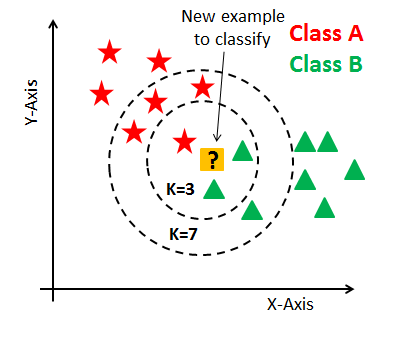

Рекомендации по реализации:
- Используйте `numpy` для представления данных в виде массивов, чтобы минимизировать преобразования.
- Избегайте циклов по всем объектам, по возможности используйте векторизированные операции.
- Обратите внимание на методы [np.linalg.norm()](https://numpy.org/doc/stable/reference/generated/numpy.linalg.norm.html) и [np.argsort()](https://numpy.org/doc/stable/reference/generated/numpy.argsort.html), а также на класс `collections.Counter`.
- Особый плюс, если учтёте обработку возможных ошибок.

In [24]:
import numpy as np
from collections import Counter

class KNN:
    def __init__(self, k:int):
        if k <= 0:
            raise ValueError("Недопустимое значение параметра k")
        
        self.k = k
        self._X = None 
        self._y = None 

    def fit(self, X, y):
        self._X = np.asarray(X, dtype=float)
        self._y = np.array(y)
        
        if not (X.ndim == 2 and y.ndim == 1):
            raise ValueError("Неверные размерности")
        if X.shape[0] != y.shape[0]:
            raise ValueError("Размерности X и y несовместимы")

    def predict(self, X):
        X = np.asarray(X, dtype=float)
        
        if X.ndim != 2:
            raise ValueError("X должен быть матрицей")
        if X.shape[1] != self._X.shape[1]:
            raise ValueError("Недопустимое количество признаков")
        
        distances = np.apply_along_axis(
            lambda x: self.count_distance(x, self._X),
            axis=1,
            arr=X
        )
        knn_idx = np.argsort(distances, axis=1)[:, :self.k]
        knn = self._y[knn_idx]

        return np.apply_along_axis(lambda x: Counter(x).most_common(1)[0][0], axis=1, arr=knn)


    def count_distance(self, x, y):
        return np.linalg.norm(x - y, ord=2, axis=1)

In [25]:
# Не меняйте файл!
def test_knn(KNN):
  knn = KNN(k=1)
  X_train =  np.array([[1, 1], [2, 2]])
  y_train =  np.array([0, 1])
  X_test =  np.array([[1.5, 1.5]])
  knn.fit(X_train, y_train)
  assert knn.predict(X_test) == [0]

  knn = KNN(k=3)
  X_train = np.array([[1, 1], [2, 2], [3, 3], [4, 4], [5, 5], [6, 6], [7, 7], [8, 8], [9, 9], [10, 10]])
  y_train = np.array([0, 0, 0, 0, 1, 1, 1, 1, 1, 1])
  X_test = np.array([[9.5, 9.5]])
  knn.fit(X_train, y_train)
  assert knn.predict(X_test) == [1]

  knn = KNN(k=3)
  X_train = np.array([[1, 1], [2, 2], [3, 3], [4, 4], [5, 5], [6, 6], [7, 7], [8, 8], [9, 9], [10, 10]])
  y_train = np.array([0, 0, 0, 0, 1, 1, 1, 1, 1, 1])
  X_test = np.array([[5.5, 5.5]])
  knn.fit(X_train, y_train)
  assert knn.predict(X_test) == [1]

  knn = KNN(k=3)
  X_train = np.array([[1, 1], [2, 2], [3, 3], [4, 4], [5, 5], [6, 6], [7, 7], [8, 8], [9, 9], [10, 10]])
  y_train = np.array([0, 0, 0, 0, 1, 1, 1, 1, 1, 1])
  X_test = np.array([[15, 15]])
  knn.fit(X_train, y_train)
  assert knn.predict(X_test) == [1]

  knn = KNN(k=3)
  X_train = np.array([[1, 1], [2, 2], [3, 3], [4, 4], [5, 5], [6, 6], [7, 7], [8, 8], [9, 9], [10, 10]])
  y_train = np.array([0, 0, 0, 0, 1, 1, 1, 1, 1, 1])
  X_test = np.array([[5, 5], [2, 2]])
  knn.fit(X_train, y_train)
  assert all(knn.predict(X_test) == [1, 0])

In [26]:
# Если тесты эти пройдены, то все верно!
test_knn(KNN)

**Задача 2.2 (0.5 балла)** Протестируйте ваш алгоритм на данных о пингвинах. Выведите лучший получившийся результат на тестовой выборке.

In [27]:
best_k = best_accuracy = 0

for k in range(1, 26):
    model = KNN(k)
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)
    accuracy = (y_pred == y_test).mean()
    
    if (accuracy > best_accuracy):
        best_accuracy = accuracy
        best_k = k
        
print(f"Лучшее k: {best_k} с точностью {best_accuracy:.4f} на test.")

Лучшее k: 1 с точностью 0.7653 на test.


### Задание 3: Линейная регрессия.

В этом задании мы рассмотрим различные аспекты построения линейной модели. Мы будем работать с одним из классических наборов данных в статистике, содержащим информацию о бриллиантах. Описание можно посмотреть [здесь](https://www.kaggle.com/shivam2503/diamonds).

In [28]:
data = pd.read_csv('diamonds.csv')
data.head(5)

,Unnamed: 0,carat,cut,color,clarity,depth,table,price,x,y,z
0,1,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,2,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,3,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,4,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,5,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


Мы будем решать задачу предсказания цены бриллианта `price` в зависимости от его характеристик.

**Задача 3.1 (0.2 балла)** Есть ли в наборе данных пропущенные значения? Если да, удалите их.
Есть ли в наборе данных бессмысленные столбцы (признаки, не несущие дополнительной информации)? Если да, то удалите их.

In [29]:
data.isna().sum()

Unnamed: 0    0
carat         0
cut           0
color         0
clarity       0
depth         0
table         0
price         0
x             0
y             0
z             0
dtype: int64

Пропуски в датасете отсутствуют

Но есть столбец `Unnamed: 0`, в котором просто айди лежит, поэтому удалим его

In [30]:
data = data.drop(columns=["Unnamed: 0"])

In [31]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   carat    53940 non-null  float64
 1   cut      53940 non-null  str    
 2   color    53940 non-null  str    
 3   clarity  53940 non-null  str    
 4   depth    53940 non-null  float64
 5   table    53940 non-null  float64
 6   price    53940 non-null  int64  
 7   x        53940 non-null  float64
 8   y        53940 non-null  float64
 9   z        53940 non-null  float64
dtypes: float64(6), int64(1), str(3)
memory usage: 4.1 MB


**Задача 3.2 (0.2 балла)** Линейная регрессия основана на предположении о линейной связи между признаками и целевой переменной, а потому перед выбором переменных для включения в модель имеет смысл проверить, насколько эта связь выполняется. Для следующих пунктов нам также потребуются выборочные корреляции между признаками. Постройте матрицу корреляций между всеми вещественными признаками и целевой переменной (то есть в этой матрице будет $k+1$ строка, где $k$ – количество вещественных признаков).

Какие вещественные признаки имеют наибольшую корреляцию с целевой переменной?

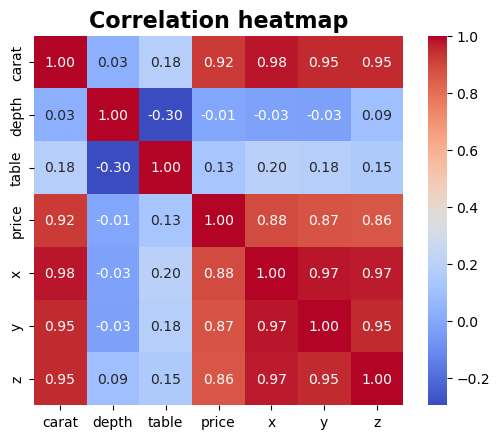

In [32]:
import seaborn as sns

ax = sns.heatmap(data.corr(numeric_only=True), annot=True, fmt=".2f", cmap="coolwarm")
ax.set_title("Correlation heatmap", fontweight="bold", fontsize=16)
ax.set_aspect("equal")

Наибольшую корреляцию с целевой переменной имеют: `carat` (масса) и его размерности по трём осям `x`, `y`, `z`

**Задача 3.3 (0.2 балла)** Так как линейная модель складывает значения признаков с некоторыми весами, нам нужно аккуратно обработать категориальные признаки. Закодируйте категориальные признаки методом OneHot-кодирования (`pd.get_dummies()` или `OneHotEncoder` из `sklearn`).

In [33]:
data = pd.get_dummies(data, columns=["cut", "color", "clarity"], dtype=np.int8)
data.sample()

,carat,depth,table,price,x,y,z,cut_Fair,cut_Good,cut_Ideal,...,color_I,color_J,clarity_I1,clarity_IF,clarity_SI1,clarity_SI2,clarity_VS1,clarity_VS2,clarity_VVS1,clarity_VVS2
52189,0.7,62.4,56.0,2478,5.66,5.69,3.54,0,0,1,...,0,0,0,0,1,0,0,0,0,0


**Задача 3.4 (0.2 балла)** Разделите выборку на тренировочную и тестовую. Долю тестовой выборки укажите равной 0.3.

In [34]:
X, y = data.drop(columns=["price"]), data["price"]

In [35]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)

**Задача 3.5 (0.3 балла)** Зачастую при использовании линейных моделей вещественные признаки масштабируются. При этом оценки коэффициентов теряют прямую статистическую интерпретацию ("при увеличении $X_1$ на 1, $y$ увеличивается на $w_1$"), но приобретают свойства, полезные в задачах машинного обучения. В этой задаче стандартизируйте вещественные признаки в тренировочной и тестовой выборках с помощью `StandardScaler`.

Объясните, как это повлияет на интерпретацию коэффициентов линейной регрессии.

In [36]:
numeric_cols = ["carat", "depth", "table", "x", "y", "z"]

scaler = StandardScaler()
X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])

После стандартизации коэффициенты становятся сопоставимыми между собой  и по ним можно судить о том, какой признак несет больший вклад в стоимость

In [37]:
X_train.sample()

,carat,depth,table,x,y,z,cut_Fair,cut_Good,cut_Ideal,cut_Premium,...,color_I,color_J,clarity_I1,clarity_IF,clarity_SI1,clarity_SI2,clarity_VS1,clarity_VS2,clarity_VVS1,clarity_VVS2
24803,1.761066,-1.357313,-0.650945,1.642935,1.653669,1.426303,0,1,0,0,...,0,0,0,0,1,0,0,0,0,0


**Задача 3.6 (0.2 балла)** Оцените линейную регрессию на тренировочной выборке. Выведите среднеквадратичную ошибку на тренировочной и тестовой выборках.

In [38]:
from sklearn.linear_model import LinearRegression

def mean_squared_error(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)

linear_regression = LinearRegression()

linear_regression.fit(X_train, y_train)
y_train_pred = linear_regression.predict(X_train)
y_test_pred = linear_regression.predict(X_test)

print(f"MSE на train: {mean_squared_error(y_train, y_train_pred):.2f}")
print(f"MSE на test: {mean_squared_error(y_test, y_test_pred):.2f}")

MSE на train: 1273725.19
MSE на test: 1284882.30


**Задача 3.7 (0.3 балла)** Изучите [документацию](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html) модуля `LinearRegression` и выведите полученные оценки коэффициентов. Назовите вещественные переменные, оценки коэффициентов которых по модулю на порядок превышают оценки прочих вещественных переменных.

In [39]:
coefs = linear_regression.coef_
for i in range(X_test.shape[1]):
    print(f"{X.columns[i]}: {coefs[i]}")

carat: 5406.683626788458
depth: -96.18576147374831
table: -55.79355409801203
x: -1196.2022324476816
y: -6.874072465107069
z: -30.137355461648504
cut_Fair: -584.4986090587306
cut_Good: -10.109393355555737
cut_Ideal: 261.4851386306432
cut_Premium: 189.2904947058693
cut_Very Good: 143.83236907777447
color_D: 820.0211617246737
color_E: 625.1660889427684
color_F: 546.2597265524984
color_G: 349.0585733206848
color_H: -138.32160303282987
color_I: -647.2424030970616
color_J: -1554.9415444107324
clarity_I1: -3745.31479469958
clarity_IF: 1506.020391840558
clarity_SI1: -150.32953256237798
clarity_SI2: -1114.3516255937764
clarity_VS1: 765.4180435756173
clarity_VS2: 445.3532862082361
clarity_VVS1: 1168.9263903423812
clarity_VVS2: 1124.2778408889355


Наибольший вес по модулю имеют: `carat` (масса сильно увеличивает цену) и `clarity_I1` (чистота I1 сильно понижает цену) 

**Задача 3.8 (0.5 балла)** Как можно заметить из анализа корреляционной матрицы в задаче 3.3, между некоторыми признаками имеется сильная корреляция, что может быть индикатором проблемы *мультиколлинеарности*. Различия в порядке коэффициентов, выявленные в предыдущей задаче также намекают на её присутствие. Как известно, для решения этой проблемы можно либо исключить некоторые признаки из модели, либо использовать регуляризацию. Мы воспользуемся вторым вариантом.

Вспомним, что смысл регуляризации заключается в том, чтобы изменить функцию потерь так, чтобы устранить проблемы, появляющиеся из-за мультиколлинеарности. При L1-регуляризации предлагается минимизировать следующую функцию потерь:

$$
\|y - X\hat{w}\|^2 + \alpha\sum_{i=1}^k|w_i|
$$

Такая модель называется Lasso-регрессией.

При L2-регуляризации предлагается минимизировать следующую функцию потерь:

$$
\|y - X\hat{w}\|^2 + \alpha\|w\|^2
$$

Такая модель называется Ridge-регрессией.

Обучите Lasso-регрессию и Ridge-регрессию, установив гиперпараметр регуляризации равным 10. Для этого используйте модули `Lasso` и `Ridge` из `sklearn`. Сильно ли уменьшились веса? Сделайте вывод о том, насколько сильно проблема мультиколлинеарности проявлялась в изначальной регрессии.

In [40]:
from sklearn.linear_model import Lasso


lasso = Lasso(alpha=10)

lasso.fit(X_train, y_train)

coefs = lasso.coef_
for i in range(X_train.shape[1]):
    print(f"{X.columns[i]}: {coefs[i]}")

carat: 4904.404808043241
depth: -105.35071344065193
table: -74.32128223465617
x: -767.8743827124044
y: -0.0
z: -35.48094940583169
cut_Fair: -438.0493206484242
cut_Good: -43.58989539219389
cut_Ideal: 95.60039756143632
cut_Premium: 0.0
cut_Very Good: 0.0
color_D: 323.36935042576243
color_E: 168.84507739285536
color_F: 98.40097891008729
color_G: 0.0
color_H: -426.0217168319835
color_I: -869.5020056101794
color_J: -1666.9229212130135
clarity_I1: -3522.05328752129
clarity_IF: 669.1787307211363
clarity_SI1: -625.2987913058946
clarity_SI2: -1528.9181333040617
clarity_VS1: 162.0680284546246
clarity_VS2: -20.579686073416717
clarity_VVS1: 501.335011877763
clarity_VVS2: 504.1138154175061


In [41]:
from sklearn.linear_model import Ridge


ridge = Ridge(alpha=10)

ridge.fit(X_train, y_train)

coefs = ridge.coef_
for i in range(X_train.shape[1]):
    print(f"{X.columns[i]}: {coefs[i]}")

carat: 5364.475528432475
depth: -94.53539322717236
table: -56.243565387142446
x: -1151.3451929469638
y: -8.946729064298879
z: -34.35971129173801
cut_Fair: -587.0089379005187
cut_Good: -10.007536250025574
cut_Ideal: 262.4511427505519
cut_Premium: 189.382833687908
cut_Very Good: 145.1824977142022
color_D: 815.2288329504827
color_E: 621.5676745630423
color_F: 542.4879483166297
color_G: 347.364200334781
color_H: -138.63578457843667
color_I: -644.1135160819434
color_J: -1543.8993555042641
clarity_I1: -3676.6411752440285
clarity_IF: 1487.269772127003
clarity_SI1: -158.00578567586868
clarity_SI2: -1117.6810498043922
clarity_VS1: 755.8243722624754
clarity_VS2: 437.3692122929986
clarity_VVS1: 1157.7394055633704
clarity_VVS2: 1114.1252484789106


При Lasso были откинуты 4 признака и остальные веса значительно уменьшились по модулю. Это значит что некоторые признаки коррелировали между собой.

При Ridge веса изменились незначительно, но стали меньше по модулю

**Задача 3.9 (0.5 балла)** Как обсуждалось на семинарах, Lasso-регрессию можно использовать для отбора наиболее информативных признаков. Для следующих значений параметра регуляриазции $\alpha$: 0.1, 1, 10, 100, 200 –  обучите Lasso- и Ridge-регрессии и постройте график измненения евклидовой нормы весов (`np.linalg.norm()` от вектора оценок коэффициентов) в зависимости от параметра $\alpha$. Как известно, норма является численной характеристикой величины вектора, а потому по норме можно судить о том, насколько большие элементы содержит вектор оценок коэффициентов.

Какой метод сильнее снижает норму коэффициентов? Поясните, почему Lasso-регрессию часто используют для отбора признаков.

In [42]:
alpha_values = [0.1, 1, 10, 100, 200]

lasso_norms = [
    np.linalg.norm(Lasso(a).fit(X_train, y_train).coef_, ord=2)
    for a in alpha_values
]

ridge_norms = [
    np.linalg.norm(Ridge(a).fit(X_train, y_train).coef_, ord=2)
    for a in alpha_values
]

/home/variaxxx/miniconda3/envs/ead/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 7.365e+07, tolerance: 6.003e+07
  model = cd_fast.enet_coordinate_descent(


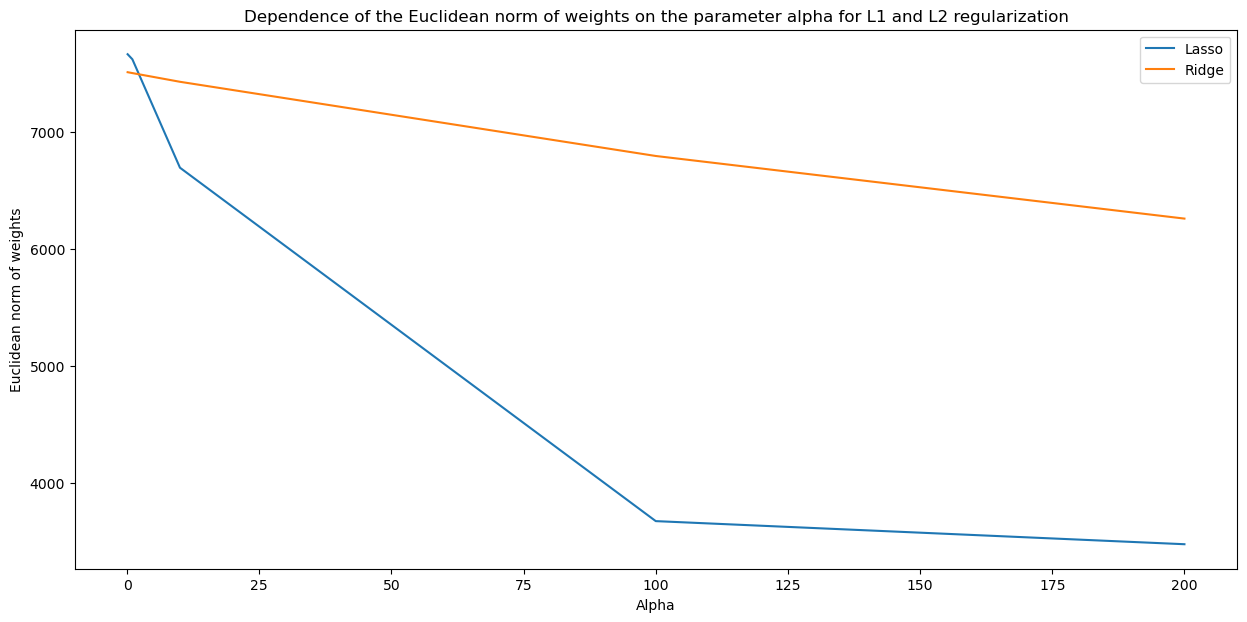

In [43]:
plt.figure(figsize=(15, 7))

plt.plot(alpha_values, lasso_norms, label="Lasso")
plt.plot(alpha_values, ridge_norms, label="Ridge")

plt.title("Dependence of the Euclidean norm of weights on the parameter alpha for L1 and L2 regularization")
plt.xlabel("Alpha")
plt.ylabel("Euclidean norm of weights")
plt.legend()

plt.show()

По графику видно, что сильнее снижает норму коэффициентов метод `Lasso`.

`Lasso` часто используют для отбора признаков, т.к. он может занулять некоторые признаки (особенность L1 регуляризации). Ridge же будет делать их околонулевыми. 

**Задача 3.10 (0.5 балла)**
В зависимости от значения параметра $\alpha$ в Lasso-регрессии зануляются разные оценки коэффициентов. Оптимальное значение $\alpha$ можно подобрать, например, при помощи кросс-валидации по тренировочной выборке.

Для проведения кросс-валидации можно использовать модуль `LassoCV`. Этот модуль принимает список значений $\alpha$ (параметр `alphas`) и при обучении проводит кросс-валидацию для каждого значения из этого списка, сохраняя MSE на каждом участке кросс-валидации (количество участков – параметр `cv`) в матрицу ошибок (то есть итоговая матрица будет иметь размер `len(alphas)` $\times$ `cv`). После обучения модели матрицу ошибок можно получить, обратившись к атрибуту `.mse_path_`.

Заметим, что модель может использовать $\alpha$ не в том порядке, в котором вы подаёте их в функцию: для определения порядка используйте атрибут `.alphas_` Установите количество участков для кросс-валидации (параметр `cv`) равным 5.

Усредните ошибки для каждого значения $\alpha$ (то есть по строкам матрицы ошибок) и выберите то значение, которое даёт наибольшее качество.

In [44]:
from sklearn.linear_model import LassoCV


lassocv = LassoCV(cv=5, alphas=alpha_values)
lassocv.fit(X_train, y_train)

errors_mat = pd.DataFrame(lassocv.mse_path_, index=lassocv.alphas_)
errors_mat

/home/variaxxx/miniconda3/envs/ead/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 7.365e+07, tolerance: 6.003e+07
  model = cd_fast.enet_coordinate_descent(


,0,1,2,3,4
200.0,2.383130e+06,2.433706e+06,2.323026e+06,2.464217e+06,2.577302e+06
100.0,2.174124e+06,2.229293e+06,2.124216e+06,2.253600e+06,2.377576e+06
10.0,1.266650e+06,1.303220e+06,1.234148e+06,1.304937e+06,1.466328e+06
1.0,1.213765e+06,1.266288e+06,1.208675e+06,1.268981e+06,1.433553e+06
0.1,1.212231e+06,1.266200e+06,1.209406e+06,1.268954e+06,1.433486e+06


In [45]:
mean_errors = errors_mat.mean(axis=1)
mean_errors

200.0    2.436276e+06
100.0    2.231761e+06
10.0     1.315057e+06
1.0      1.278252e+06
0.1      1.278056e+06
dtype: float64

In [46]:
optimal_alpha = mean_errors.idxmin()
print(f"Значение alpha, дающее наибольшее качество: {optimal_alpha}")

Значение alpha, дающее наибольшее качество: 0.1


**Задача 3.11 (0.5 балла)** Обучите итоговую Lasso-регрессию с выбранным параметром $\alpha$ на тренировочной выборке. Выведите полученные коэффициенты и прокомментируйте, какие признаки оказались неинформативными, а какие – наиболее информативными. Приведите возможное смысловое объяснение этого результата.

In [47]:
final_lasso = Lasso(alpha=optimal_alpha).fit(X_train, y_train)

coefs = final_lasso.coef_
for i in range(X_test.shape[1]):
    print(f"{X.columns[i]}: {coefs[i]}")

carat: 5401.6800780137
depth: -96.26947360915906
table: -55.9756076419362
x: -1192.0694181191302
y: -6.5892853175562385
z: -30.240393662492934
cut_Fair: -725.4951394096711
cut_Good: -152.9249417487893
cut_Ideal: 117.36202835797923
cut_Premium: 44.86367862273883
cut_Very Good: -0.0
color_D: 726.0128223828592
color_E: 531.5085947931285
color_F: 452.63748830308685
color_G: 255.89142066078892
color_H: -230.4338966783394
color_I: -738.732704504262
color_J: -1645.3468862255115
clarity_I1: -4276.136100428378
clarity_IF: 964.7169995166959
clarity_SI1: -688.172599279368
clarity_SI2: -1651.5929728118704
clarity_VS1: 226.36588688811537
clarity_VS2: -92.37403305353949
clarity_VVS1: 629.2390816827807
clarity_VVS2: 585.0528093645012


/home/variaxxx/miniconda3/envs/ead/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 7.365e+07, tolerance: 6.003e+07
  model = cd_fast.enet_coordinate_descent(


Видим, что занулились признаки `y`, `cut_Very Good`, `color_G`. Это значит, что размеры бриллианта по оси Y, тип огранки "Very Good" и цвет "G" оказались излишними в данной задаче. 

Наибольшие по модулю веса имеют `carat` и `clarity_I1`. Это значит, что цена сильно зависит от размера бриллианта (очевидно) и чистота бриллианта "I1" сильно его дешевит.  

**Задача 3.12 (0.4 балла)** Сделайте предсказания обученной Lasso-регрессии на тестовой выборке и сравните среднеквадратичную ошибку с ошибкой обычной линейной регрессии из задачи 3.7. Какую модель лучше использовать для предсказаний? Приведите возможное объяснение, почему одна модель оказалась лучше другой.

In [48]:
default_mse = mean_squared_error(
    y_test,
    linear_regression.predict(X_test)
)

trained_mse = mean_squared_error(
    y_test,
    final_lasso.predict(X_test)
)

print(f"MSE для обычной линейной регрессии: {default_mse:.2f}")
print(f"MSE для обученной Lasso-регрессии: {trained_mse:.2f}")

MSE для обычной линейной регрессии: 1284882.30
MSE для обученной Lasso-регрессии: 1284832.72


In [49]:
np.abs(default_mse - trained_mse)

np.float64(49.580131479073316)

Видим, что обученная Lasso-регрессия хоть и несильно, но лучше обычной. Может быть связано с тем, что регуляризация уменьшает переобучение и отбирает полезные признаки.